Random_state:  15
              precision    recall  f1-score   support

 non-healing       1.00      0.50      0.67         2
     healing       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8

Accuracy: 87.5 %


<Figure size 40000x12000 with 0 Axes>

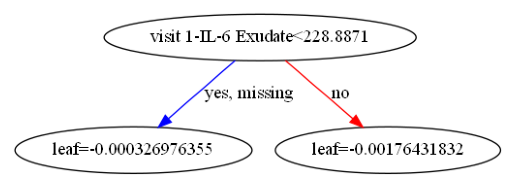

--------------------------------------------------------------------------------------------------


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from xgboost import *
from dtreeviz import model

Treatment=pd.read_csv("../AD report/full_train atra.csv")
Treatment_test=pd.read_csv("../AD report/full_test atra.csv")



X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]


X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]


#y_train = to_categorical(df_y)
#y_test = to_categorical(df_y_test)

W_tree=1
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=3



clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="hist",
                 objective="reg:absoluteerror",
                  eta=1,
                  max_depth=None,
                  subsample=0.7,
                  colsample_bytree=0.2,
                 #colsample_bylevel=0.7,
                 colsample_bynode=0.1,
                  #reg_lambda=0.1,
                 # reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.7,
                  one_drop=1,
                num_parallel_tree=5000,
                 #sample_type="weighted",
                  
                  random_state=R_state,
                  
                  
                  
    )
params = {
    "booster":"dart",
    "normalize_type":"forest",
  "colsample_bynode": 0.8,
  "learning_rate": 1,
  "max_depth": 5,
  "num_parallel_tree": 500,
  "objective": "reg:pseudohubererror",
  "subsample": 0.8,
  "tree_method": "hist",
  
}

data = X_train  # 5 entities, each contains 10 features
label = y_train
data=xgb.DMatrix(data, label=label)

clf = train(params, data, num_boost_round=1)

data = X_test  # 5 entities, each contains 10 features
label = y_test
test=xgb.DMatrix(data, label=label)

y_pred = clf.predict(test)
#y_pred = clf.predict(test, iteration_range=(0, 100))
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

#names=clf.get_booster().feature_names
#print(clf.get_booster().get_score(importance_type='weight'))

#forest_importances = pd.Series(importances, index=names)

#fig, ax = plt.subplots()
#forest_importances.plot.bar( ax=ax)
#ax.set_title("Feature importances using MDI")
#ax.set_ylabel("Mean decrease in impurity")
#fig.set_size_inches(18.5, 10.5)
#plt.show()

#f = open("out.txt", "w")
#var=clf.get_booster().get_dump()
#for line in var:
#    f.write(f"{line}\n")
#f.close()

#print(clf.predict_proba(X_test))
#print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=y_train

#from supertree import SuperTree
#st = SuperTree(
#    clf, 
#    X_train, 
#    Which_data, 
#    names, 
#    class_names
#)
# Visualize the tree
#st.show_tree(which_tree=W_tree)